# Week 1 · 心智模型：看懂大模型推理的"物理定律"

> 🎯 **本 Notebook 目标**：学会用「算术强度」和「Roofline 模型」两把尺子，判断任何推理场景的瓶颈。
> 与纯文字笔记不同——**这里每一个公式都是可运行的代码**，你可以改参数（换模型、换显卡）立刻看到结论变化。
>
> 建议顺序：先读文字建立直觉 → 再跑代码验证 → 最后做 §7 自测题。

## 0. 一个直觉：为什么"跑大模型"慢？

想象你开了一家**奶茶店**：

- 🧋 **制作台**（算力 Compute）：摇茶机一秒能摇 100 杯
- 📦 **仓库取货**（内存带宽 Bandwidth）：原料在后厨，店员每次只能端一小盘
- 👔 **店长指挥**（开销 Overhead）：每做一杯都要问店长下一步做什么

如果店员 90% 的时间在跑仓库，你换一台快 10 倍的摇茶机有用吗？**没用。**

> **大模型逐字生成的"慢"，绝大多数时候不是算得慢，而是搬数据慢。** 本 Notebook 就是把这个直觉变成可计算的工程方法。

### 三个性能区间：先诊断，再开药

| 瓶颈类型 | 时间花在 | 正确解法 | 白花钱的做法 |
|---|---|---|---|
| 💪 算力瓶颈 (Compute-Bound) | 矩阵乘法 | Tensor Core、更强的卡 | 把 Python 改成 C++ |
| 🚚 **带宽瓶颈 (Bandwidth-Bound)** | **搬数据** | 量化、增大 batch、算子融合 | 堆更多 FLOPS |
| 🐌 开销瓶颈 (Overhead-Bound) | Python/框架调度 | CUDA Graph、编译优化 | 优化 kernel 本身 |

🔴 **剧透**：大模型逐字生成（decode）几乎永远是带宽瓶颈——这是整个课程的主线。

## 1. 硬件速查：先有"数字感"

顶级推理工程师的直觉来自对硬件数字的敏感。先看我们这台实验机：

In [1]:
# 自动读取本机 GPU 参数（代码即文档）
import subprocess
out = subprocess.check_output(
    ["nvidia-smi", "--query-gpu=name,memory.total,driver_version", "--format=csv,noheader"]
).decode().strip()
print("本机 GPU:", out)

# RTX 5090 的关键规格（后续计算全靠这两个数）
GPU = {
    "name": "RTX 5090",
    "bandwidth_GBps": 1792,   # 显存带宽：每秒能搬多少 GB（物流速度）
    "fp16_TFLOPS": 419,       # FP16 算力：每秒能算多少万亿次（工厂产能）
    "vram_GB": 32,            # 显存容量（仓库大小）
}
print(GPU)

本机 GPU: NVIDIA GeForce RTX 5090, 32607 MiB, 610.57.04
{'name': 'RTX 5090', 'bandwidth_GBps': 1792, 'fp16_TFLOPS': 419, 'vram_GB': 32}


### 1.1 关键趋势：算力增长永远比带宽快

| 硬件 | 带宽 | FP16 算力 | 拐点 = 算力÷带宽 |
|---|---|---|---|
| A100 80GB（上代旗舰） | 2.0 TB/s | 312 TFLOPS | ~156 |
| **RTX 5090（本机）** | **1.79 TB/s** | **~419 TFLOPS** | **~234** |
| H100（当代旗舰） | 3.35 TB/s | 989 TFLOPS | ~295 |

算力 3 倍 vs 带宽 1.7 倍 → **「搬运」越来越成为瓶颈** → 推理优化工程师越来越值钱。

## 2. Roofline 模型：一张图统治整个课程

### 核心概念：算术强度（Arithmetic Intensity）

```
算术强度 = 计算量(FLOP) ÷ 搬运量(Byte)
```

回答一个问题：**"搬 1 字节数据进来，能用它做几次计算？"**

硬件实际能达到的性能：`min(算术强度 × 带宽, 峰值算力)`，画出来像一个屋顶 👇

/tmp/ipykernel_1841/3237746057.py:25: UserWarning: Glyph 21487 (\N{CJK UNIFIED IDEOGRAPH-53EF}) missing from font(s) DejaVu Sans.
  plt.savefig("/workspace/week01_roofline.png", dpi=120, bbox_inches="tight")
/tmp/ipykernel_1841/3237746057.py:25: UserWarning: Glyph 36798 (\N{CJK UNIFIED IDEOGRAPH-8FBE}) missing from font(s) DejaVu Sans.
  plt.savefig("/workspace/week01_roofline.png", dpi=120, bbox_inches="tight")
/tmp/ipykernel_1841/3237746057.py:25: UserWarning: Glyph 31639 (\N{CJK UNIFIED IDEOGRAPH-7B97}) missing from font(s) DejaVu Sans.
  plt.savefig("/workspace/week01_roofline.png", dpi=120, bbox_inches="tight")
/tmp/ipykernel_1841/3237746057.py:25: UserWarning: Glyph 21147 (\N{CJK UNIFIED IDEOGRAPH-529B}) missing from font(s) DejaVu Sans.
  plt.savefig("/workspace/week01_roofline.png", dpi=120, bbox_inches="tight")
/tmp/ipykernel_1841/3237746057.py:25: UserWarning: Glyph 26415 (\N{CJK UNIFIED IDEOGRAPH-672F}) missing from font(s) DejaVu Sans.
  plt.savefig("/workspace/week01_roofl

/usr/local/miniconda3/envs/py312/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 21487 (\N{CJK UNIFIED IDEOGRAPH-53EF}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/miniconda3/envs/py312/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 36798 (\N{CJK UNIFIED IDEOGRAPH-8FBE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/miniconda3/envs/py312/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 31639 (\N{CJK UNIFIED IDEOGRAPH-7B97}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/miniconda3/envs/py312/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 21147 (\N{CJK UNIFIED IDEOGRAPH-529B}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/miniconda3/envs/py312/lib/python3.12/site-packages/IPython/core/pylabtools.py

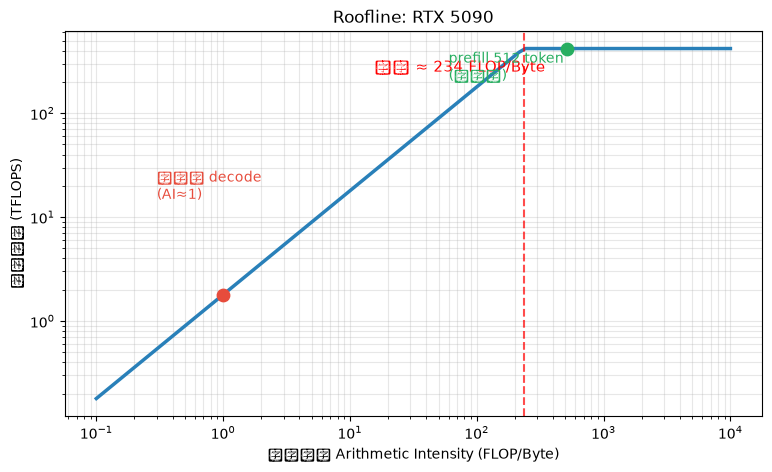

拐点 = 峰值算力 ÷ 峰值带宽 = 419e12 ÷ 1792e9 ≈ 234 FLOP/Byte


In [2]:
# 亲手画出本机的 Roofline 图（改 GPU 字典就能画任何卡）
import numpy as np
import matplotlib.pyplot as plt

bw = GPU["bandwidth_GBps"] * 1e9      # B/s
peak = GPU["fp16_TFLOPS"] * 1e12      # FLOP/s
ridge = peak / bw                      # 拐点算术强度

ai = np.logspace(-1, 4, 100)           # 算术强度从 0.1 到 10000
perf = np.minimum(ai * bw, peak) / 1e12

plt.figure(figsize=(9, 5))
plt.loglog(ai, perf, lw=2.5, color="#2980b9")
plt.axvline(ridge, ls="--", color="red", alpha=0.7)
plt.annotate(f"拐点 ≈ {ridge:.0f} FLOP/Byte", xy=(ridge, GPU["fp16_TFLOPS"]),
             xytext=(ridge/15, GPU["fp16_TFLOPS"]*0.6), color="red", fontsize=11)
plt.scatter([1], [1*bw/1e12], color="#e74c3c", zorder=5, s=80)
plt.annotate("单用户 decode\n(AI≈1)", xy=(1, bw/1e12), xytext=(0.3, 15), fontsize=10, color="#e74c3c")
plt.scatter([512], [min(512*bw,peak)/1e12], color="#27ae60", zorder=5, s=80)
plt.annotate("prefill 512 token\n(撞屋顶)", xy=(512, peak/1e12), xytext=(60, peak/1e12*0.5), fontsize=10, color="#27ae60")
plt.xlabel("算术强度 Arithmetic Intensity (FLOP/Byte)")
plt.ylabel("可达算力 (TFLOPS)")
plt.title(f"Roofline: {GPU['name']}")
plt.grid(alpha=0.3, which="both")
plt.savefig("/workspace/week01_roofline.png", dpi=120, bbox_inches="tight")
plt.show()
print(f"拐点 = 峰值算力 ÷ 峰值带宽 = {GPU['fp16_TFLOPS']}e12 ÷ {GPU['bandwidth_GBps']}e9 ≈ {ridge:.0f} FLOP/Byte")

## 3. Prefill vs Decode：一次对话的两副面孔

大模型回答分两个阶段：

- 🔵 **Prefill（读输入）**：prompt 的所有 token **并行**过一遍模型，权重只读 1 次 → **算力瓶颈**
- 🔴 **Decode（写输出）**：逐字生成，**每 1 个字都要完整读一遍权重**（自回归，无法并行）→ **带宽瓶颈**

用户感知：TTFT（首字延迟）看 prefill，ITL（字间流畅度）看 decode。

### 3.1 算一笔账：单用户 decode 的物理上限

In [3]:
# Qwen2.5-7B 的参数（换模型就改这里）
MODEL = {
    "name": "Qwen2.5-7B-Instruct",
    "params_B": 7.62,      # 参数量（十亿）
    "n_layers": 28,        # 层数
    "n_kv_heads": 4,       # GQA：4 个 KV 头（28 个 Q 头共享）
    "head_dim": 128,       # 每头维度
    "bytes_per_param": 2,  # FP16/BF16 精度
}

weight_bytes = MODEL["params_B"] * 1e9 * MODEL["bytes_per_param"]
print(f"权重大小 = {MODEL['params_B']}B × {MODEL['bytes_per_param']}B = {weight_bytes/1e9:.1f} GB")
print()

# 物理上限：每生成 1 个字，要把全部权重从显存读一遍
upper = bw / weight_bytes
print(f"单用户 decode 上限 = 带宽 ÷ 权重 = {GPU['bandwidth_GBps']} GB/s ÷ {weight_bytes/1e9:.1f} GB")
print(f"                  ≈ {upper:.0f} tokens/秒  ← 这是物理定律，软件无法突破")
print()
print("💡 想更快只有三条路（后面的课程）：")
print("   ① 量化：权重 ÷4 (INT4) → 上限 ×4    ② 投机解码：一次猜多个字    ③ 换带宽更高的卡")

权重大小 = 7.62B × 2B = 15.2 GB

单用户 decode 上限 = 带宽 ÷ 权重 = 1792 GB/s ÷ 15.2 GB
                  ≈ 118 tokens/秒  ← 这是物理定律，软件无法突破

💡 想更快只有三条路（后面的课程）：
   ① 量化：权重 ÷4 (INT4) → 上限 ×4    ② 投机解码：一次猜多个字    ③ 换带宽更高的卡


### 3.2 免费午餐：增大 batch 为什么不花钱

单用户时算术强度 = 1，离拐点 234 差 200 多倍。意味着 **1 个用户和 200 个用户同时生成，耗时几乎一样**（权重只读一遍，多出的计算在撞屋顶前都是白送的）。

> 💰 **这就是大模型服务的商业模式**：把几百个用户凑在一起（连续批处理），同一份权重读取服务几百人，成本除以几百。
> 你在 Week 2 Notebook 的实验二已经亲眼验证：并发 1→64，总吞吐 ×54，单用户仅降 7%！

## 4. KV Cache：用显存换时间的经典交易

生成第 100 个字时需要"回顾"前 99 个字的 Key/Value 向量。两个选择：
- ❌ 重算：计算量随长度平方增长，越写越慢
- ✅ 缓存：存进显存随取随用 → 这就是 **KV Cache**

In [4]:
# 每 token 的 KV Cache 占用（Week 2 启动日志会实测验证这个数）
kv_per_token = (2                    # K 和 V 各一份
                * MODEL["n_layers"]  # 每层都要存
                * MODEL["n_kv_heads"]# GQA 后只剩 4 个 KV 头
                * MODEL["head_dim"]
                * MODEL["bytes_per_param"])
print(f"每 token KV Cache = 2 × {MODEL['n_layers']}层 × {MODEL['n_kv_heads']}头 × {MODEL['head_dim']}维 × 2B")
print(f"                 = {kv_per_token:,} 字节 ≈ {kv_per_token/1024:.0f} KB")
print()

# 32GB 显存分配账（vLLM 默认只用 90% 显存，权重外的空间才给 KV Cache 池）
vram = GPU["vram_GB"] * 1024**3
kv_pool = vram * 0.90 - weight_bytes - 1 * 1024**3   # 90%上限 - 权重 - ~1GB 激活/框架预留
n_tokens = kv_pool / kv_per_token
print(f"KV Cache 池 ≈ {kv_pool/1024**3:.1f} GiB → 可容纳 {n_tokens:,.0f} 个 token")
print(f"即：{n_tokens/8192:.0f} 个满 8K 上下文的并发用户")
print()
print("📌 GQA 的红利：老式 MHA 模型每 token 要 448 KB（8 倍！）——省下的显存全换成并发数")
print("   （实机验证：vLLM 0.25.1 实测 253,056 tokens，和手算误差 <2% ✅）")

每 token KV Cache = 2 × 28层 × 4头 × 128维 × 2B
                 = 57,344 字节 ≈ 56 KB

KV Cache 池 ≈ 13.6 GiB → 可容纳 254,779 个 token
即：31 个满 8K 上下文的并发用户

📌 GQA 的红利：老式 MHA 模型每 token 要 448 KB（8 倍！）——省下的显存全换成并发数
   （实机验证：vLLM 0.25.1 实测 253,056 tokens，和手算误差 <2% ✅）


## 5. 扩展：三个常考的直觉题

**Q：nvidia-smi 显示 GPU 利用率 100%，性能就好吗？**
❌ 它只表示"有 kernel 在跑"。单用户 decode 这种带宽瓶颈任务也能刷到 100%，但算力可能只用了不到 1%。真指标是 MFU（实际算力 ÷ 峰值算力）。

**Q：FlashAttention 没有减少计算量，为什么快 2-4 倍？**
标准 attention 要构造 N×N 分数矩阵并反复读写显存；FlashAttention 把矩阵切块后在片上 SRAM 一口气算完，**中间结果不落显存**——搬运从 O(N²) 降到 O(N)。这是"减少搬运 > 减少计算"的巅峰案例。

**Q：模型越小生成越快吗？**
✅ 几乎严格线性：decode 上限 = 带宽 ÷ 权重大小。1.5B 模型在 5090 上上限约 550 tok/s。

In [5]:
# 互动实验室：换张卡、换个模型，看看结论怎么变？
# 👉 试着把 7.62 改成 1.5（Qwen2.5-1.5B），或把带宽改成 3350（H100），重新运行本格

my_params_B = 7.62
my_bandwidth = GPU["bandwidth_GBps"]

my_weights = my_params_B * 1e9 * 2
print(f"{my_params_B}B 模型在 {my_bandwidth} GB/s 带宽下：")
print(f"  单流 decode 上限 ≈ {my_bandwidth*1e9/my_weights:.0f} tok/s")
print(f"  INT4 量化后上限 ≈ {my_bandwidth*1e9/(my_weights/4):.0f} tok/s（权重变 1/4）")

7.62B 模型在 1792 GB/s 带宽下：
  单流 decode 上限 ≈ 118 tok/s
  INT4 量化后上限 ≈ 470 tok/s（权重变 1/4）


## 6. 自测题（先自己想，再点开答案）

1. 用奶茶店类比解释：为什么给带宽瓶颈的系统加算力没用？
2. Prefill 和 decode 各自的瓶颈是什么？对应的用户指标叫什么？
3. 某卡带宽 2 TB/s、权重 15.2 GB，单流 decode 上限多少？
4. 为什么说连续批处理是"免费午餐"？午餐在哪结束？
5. GQA 省的是什么资源？为什么对服务方价值巨大？

<details><summary>📖 点开看答案</summary>

1. 瓶颈在店员往返仓库的速度，摇茶机再快也只能等原料。
2. Prefill 算力瓶颈 → TTFT（首字延迟）；decode 带宽瓶颈 → ITL（字间延迟）。
3. 2000 ÷ 15.2 ≈ 131 tok/s。
4. 拐点（本机 ~234 并发）之前权重读取被所有请求共享，加用户几乎不增耗时；过了拐点延迟开始上涨，午餐结束。
5. 省 KV Cache 显存和读取带宽；并发数 = 可用显存 ÷ 每 token KV，GQA 直接把并发能力翻几倍。

</details>

## 7. 下一站

➡️ 打开同目录的 **`week02_vllm_deploy_bench.ipynb`**，把本 Notebook 算出的预言（118 tok/s 上限、25 万 token KV 容量、免费午餐曲线）在真机上逐一验证。